## Linear Regressor

In [6]:
# Libraries and functions
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from models import *


# Function to flatten images based on their dimensionality
def preprocessing_input(x):
    if x.dim() == 4:  # Images have shape (batch_size, channels, height, width)
        return x.view(x.size(0), -1)
    elif x.dim() == 2:
        return x 
    else:
        raise ValueError("Input have an unexpected shape. Expected either 4D tensor (batch_size, channels, height, width) or 2D tensor (batch_size, num_features).")

# # Evaluation function
# def evaluate_test(model, test_loader, num_classes=10):
#     model.eval()
#     actuals, predictions = [], []
#     with torch.no_grad():
#         for images, labels in test_loader:
#             images = preprocessing_input(images)
#             labels = labels.float().view(-1, 1)
            
#             outputs = model(images)
#             predictions.append(outputs.numpy())
#             actuals.append(labels.numpy())
    
#     predictions = np.vstack(predictions)
#     actuals = np.vstack(actuals)
    
#     # Calculate regression metrics
#     mse = mean_squared_error(actuals, predictions)
#     r2 = r2_score(actuals, predictions)
    
#     # Convert regression outputs to classification by rounding to the nearest integer
#     predicted_classes = np.round(predictions).astype(int)
#     actual_classes = actuals.astype(int)
    
#     # Ensure predictions are within the valid range [0, num_classes-1]
#     predicted_classes = np.clip(predicted_classes, 0, num_classes - 1)
#     accuracy = accuracy_score(actual_classes, predicted_classes)
    
#     print(f'Mean Squared Error: {mse:.4f}')
#     print(f'R² Score: {r2:.4f}')
#     print(f'Accuracy: {accuracy:.4f}')
    
#     return mse, r2, accuracy

from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

def evaluate_test(model, test_loader, task_type='regression', num_classes=10):
    model.eval()
    actuals, predictions = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = preprocessing_input(images)
            
            outputs = model(images)
            
            if task_type == 'regression':
                labels = labels.float().view(-1, 1)
                predictions.append(outputs.numpy())
                actuals.append(labels.numpy())
            elif task_type == 'classification':
                labels = labels.long()
                predictions.append(outputs.numpy())
                actuals.append(labels.numpy())

    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    
    if task_type == 'regression':
        # Calculate regression metrics
        mse = mean_squared_error(actuals, predictions)
        r2 = r2_score(actuals, predictions)
        
        print(f'Mean Squared Error: {mse:.4f}')
        print(f'R² Score: {r2:.4f}')
        
        return mse, r2
    
    elif task_type == 'classification':
        # Convert logits to predicted classes
        if predictions.shape[1] == 1:
            # Binary classification: apply sigmoid and threshold
            predicted_classes = (predictions > 0.5).astype(int)
            actual_classes = actuals.astype(int)
        else:
            # Multi-class classification: apply softmax and argmax
            predicted_classes = np.argmax(predictions, axis=1)
            actual_classes = np.argmax(actuals, axis=1)
        
        # Calculate classification metrics
        accuracy = accuracy_score(actual_classes, predicted_classes)
        precision = precision_score(actual_classes, predicted_classes, average='weighted')
        recall = recall_score(actual_classes, predicted_classes, average='weighted')
        f1 = f1_score(actual_classes, predicted_classes, average='weighted')
        
        print(f'Accuracy: {accuracy:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'F1 Score: {f1:.4f}')
        
        return accuracy, precision, recall, f1

# # Training function with validation
# def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
#     best_model = None
#     best_val_loss = float('inf')
#     final_model = None
#     metrics = {'loss': [], 'val_loss': []}
    
#     for epoch in range(num_epochs):
#         model.train()
#         running_loss = 0.0
        
#         for images, labels in train_loader:
#             images = preprocessing_input(images)  # Flatten the image according to its dimensionality
#             labels = labels.float().view(-1, 1)  # Convert labels to float for regression
            
#             # Zero the parameter gradients
#             optimizer.zero_grad()
            
#             # Forward pass
#             outputs = model(images)
#             loss = criterion(outputs, labels)
            
#             # Backward pass and optimize
#             loss.backward()
#             optimizer.step()
            
#             running_loss += loss.item() * images.size(0)
        
#         # Calculate average training loss
#         epoch_loss = running_loss / len(train_loader.dataset)
#         metrics['loss'].append(epoch_loss)
        
#         # Evaluate on the validation set
#         val_loss = evaluate(model, val_loader, criterion)
#         metrics['val_loss'].append(val_loss)
        
#         print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
#         # Check if this is the best model
#         if val_loss < best_val_loss:
#             best_val_loss = val_loss
#             best_model = model.state_dict()  # Save the best model
            
#         # Save the final model at the end of training
#         final_model = model.state_dict()
    
#     # Load the best model for return
#     model.load_state_dict(best_model)
#     best_model_instance = model
    
#     return best_model_instance, final_model, metrics

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, task_type='regression'):
    best_model = None
    best_val_loss = float('inf')
    final_model = None
    metrics = {'loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images = preprocessing_input(images)  # Flatten the image according to its dimensionality
            
            if task_type == 'regression':
                labels = labels.float().view(-1, 1)  # Convert labels to float for regression
            elif task_type == 'classification':
                labels = labels.long()  # Ensure labels are in long format for classification
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        # Calculate average training loss
        epoch_loss = running_loss / len(train_loader.dataset)
        metrics['loss'].append(epoch_loss)
        
        # Evaluate on the validation set
        val_loss = evaluate(model, val_loader, criterion, task_type)
        metrics['val_loss'].append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()  # Save the best model
            
        # Save the final model at the end of training
        final_model = model.state_dict()
    
    # Load the best model for return
    model.load_state_dict(best_model)
    best_model_instance = model
    
    return best_model_instance, final_model, metrics

def evaluate(model, val_loader, criterion, task_type):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = preprocessing_input(images)
            
            if task_type == 'regression':
                labels = labels.float().view(-1, 1)
            elif task_type == 'classification':
                labels = labels.long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    
    return val_loss / len(val_loader.dataset)

# # Function to evaluate the model
# def evaluate(model, data_loader, criterion):
#     model.eval()
#     total_loss = 0.0
#     with torch.no_grad():
#         for images, labels in data_loader:
#             images = preprocessing_input(images)
#             labels = labels.float().view(-1, 1)
            
#             outputs = model(images)
#             loss = criterion(outputs, labels)
#             total_loss += loss.item() * images.size(0)
    
#     avg_loss = total_loss / len(data_loader.dataset)
#     return avg_loss

# def init_LinearRegressor(train_dataset):
#     # Check if using MNIST or CIFAR-10
#     if train_dataset[0][0].shape == torch.Size([1, 28, 28]):  # MNIST
#         input_dim = 28 * 28  # 784
#         num_classes = 10
#     elif train_dataset[0][0].shape == torch.Size([3, 32, 32]):  # CIFAR-10
#         input_dim = 3 * 32 * 32  # 3072
#         num_classes = 10
#     elif train_dataset[0][0].shape == torch.Size([30]):  # AIRLINE
#         input_dim = 30
#         num_classes = 1
#     elif train_dataset[0][0].shape == torch.Size([105]):  # ADULT
#         input_dim = 105
#         num_classes = 2
#     else:
#         raise ValueError("Unsupported dataset shape")

    # return input_dim, num_classes

def plot_training_metrics(metrics, dataset):
    # Extract losses
    epochs = list(range(1, len(metrics['loss']) + 1))
    train_losses = metrics['loss']
    val_losses = metrics['val_loss']
    
    # Find the epoch with the minimum validation loss
    min_val_loss_epoch = val_losses.index(min(val_losses)) + 1
    min_val_loss = min(val_losses)
    
    # Create a plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=epochs, y=train_losses, label='Training Loss')
    sns.lineplot(x=epochs, y=val_losses, label='Validation Loss')
    
    # Mark the minimum validation loss with a star
    plt.scatter(min_val_loss_epoch, min_val_loss, color='red', marker='*', s=200, label='Min Validation Loss')
    
    # Add titles and labels
    plt.title(f'Training and Validation Loss - {dataset.upper()}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    if not os.path.exists('./images'):
        os.makedirs('./images')
    plt.savefig(f'./images/{dataset}_training_loss.png')
    plt.show()



Training on MNIST dataset


/var/folders/zx/c94b09b50v31fk6qp9h3h1cw0000gn/T/ipykernel_17417/4283870796.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_dataset = torch.load(f'datasets/{datas

Epoch [1/5], Loss: 1.6248, Val Loss: 1.5682
Epoch [2/5], Loss: 1.5604, Val Loss: 1.5556
Epoch [3/5], Loss: 1.5508, Val Loss: 1.5470
Epoch [4/5], Loss: 1.5454, Val Loss: 1.5443
Epoch [5/5], Loss: 1.5418, Val Loss: 1.5424


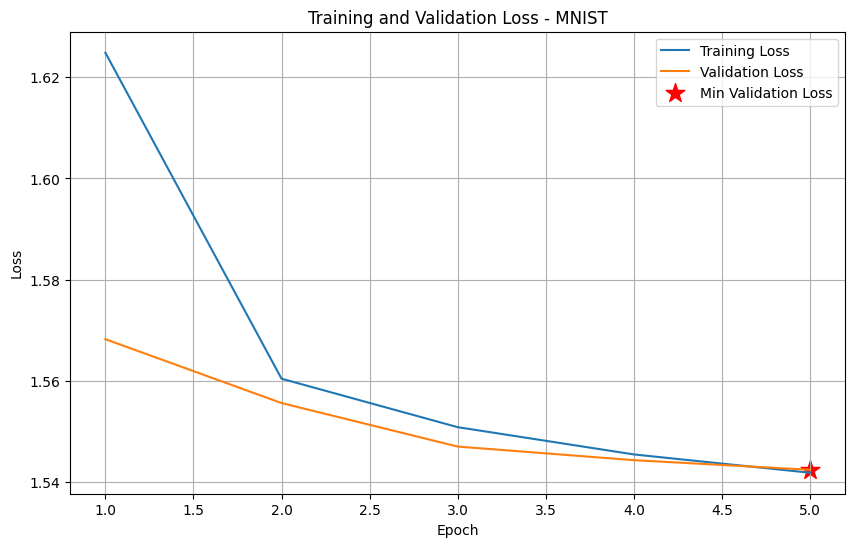

ValueError: y_true and y_pred have different number of output (1!=10)

In [9]:
# Training loop
DATASETS = ['mnist', 'cifar10', 'airline', 'adult']
EPOCHS = 5
BATCH_SIZE = 64
LEARNING_RATE = 0.001

performance = {}
for dataset in DATASETS:
    print(f'\n\nTraining on {dataset.upper()} dataset')
   
    # Load dataset
    train_dataset = torch.load(f'datasets/{dataset}_train.pt')
    test_dataset = torch.load(f'datasets/{dataset}_test.pt')

    # Split train dataset into train and validation sets
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

    # Create DataLoader
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Model, criterion, and optimizer
    # input_dim, num_classes = init_LinearRegressor(train_dataset)
    model = LinearModel(dataset_name=dataset)
    criterion = model.criterion
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)  

    # Train the model
    # best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS)
    best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=EPOCHS, task_type=model.task_type)
    plot_training_metrics(metrics, dataset)
    
    # Evaluate the model on the test set
    mse, r2, accuracy = evaluate_test(best_model, test_loader)
    print(f'  - Mean Squared Error: {mse:.4f}')
    print(f'  - R² Score: {r2:.4f}')
    print(f'  - Accuracy: {accuracy:.4f}')
    performance[dataset] = {'mse': mse, 'r2': r2, 'accuracy': accuracy}

# Save the performance metrics
if not os.path.exists('metrics'):
    os.makedirs('metrics')
torch.save(performance, 'metrics/performance.pt')

## Multilayer Perceptron (MLP)

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

dataset = 'mnist'
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, task_type='regression'):
    best_model = None
    best_val_loss = float('inf')
    final_model = None
    metrics = {'loss': [], 'val_loss': []}
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images = preprocessing_input(images)  # Flatten the image according to its dimensionality
            
            if task_type == 'regression':
                labels = labels.float().view(-1, 1)  # Convert labels to float for regression
            elif task_type == 'classification':
                labels = labels.long()  # Ensure labels are in long format for classification
            
            # Zero the parameter gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        # Calculate average training loss
        epoch_loss = running_loss / len(train_loader.dataset)
        metrics['loss'].append(epoch_loss)
        
        # Evaluate on the validation set
        val_loss = evaluate(model, val_loader, criterion, task_type)
        metrics['val_loss'].append(val_loss)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}')
        
        # Check if this is the best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()  # Save the best model
            
        # Save the final model at the end of training
        final_model = model.state_dict()
    
    # Load the best model for return
    model.load_state_dict(best_model)
    best_model_instance = model
    
    return best_model_instance, final_model, metrics

def evaluate(model, val_loader, criterion, task_type):
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images = preprocessing_input(images)
            
            if task_type == 'regression':
                labels = labels.float().view(-1, 1)
            elif task_type == 'classification':
                labels = labels.long()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
    
    return val_loss / len(val_loader.dataset)

# Example usage
model = LinearModel(dataset_name=dataset)
criterion = model.criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

# Assuming train_loader and val_loader are defined elsewhere
best_model, final_model, metrics = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs, task_type=model.task_type)

Epoch [1/10], Loss: 1.6248, Val Loss: 1.5706


KeyboardInterrupt: 